In [4]:
# IMPORT LIBRARIES ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")
from google.colab import drive
drive.mount('/content/drive')

Libraries imported successfully!
Mounted at /content/drive


In [5]:
file_path = "/content/drive/My Drive/covid_19_clean_complete.csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully!\n")

# View the first few rows
df.head()

Dataset loaded successfully!



,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [6]:
print("Shape of dataset:", df.shape)
print("\n--- INFO ---")
df.info()


Shape of dataset: (49068, 10)

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [7]:
df.isnull().sum()


,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [8]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Province/State,14664,78,Australian Capital Territory,188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country/Region,49068,187,China,6204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lat,49068.0,NaN,NaN,NaN,21.43373,24.95032,-51.7963,7.873054,23.6345,41.20438,71.7069
Long,49068.0,NaN,NaN,NaN,23.528236,70.44274,-135.0,-15.3101,21.7453,80.771797,178.065
Date,49068,188,2020-01-22,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Confirmed,49068.0,NaN,NaN,NaN,16884.904255,127300.205272,0.0,4.0,168.0,1518.25,4290259.0
Deaths,49068.0,NaN,NaN,NaN,884.17916,6313.584411,0.0,0.0,2.0,30.0,148011.0
Recovered,49068.0,NaN,NaN,NaN,7915.713479,54800.918731,0.0,0.0,29.0,666.0,1846641.0
Active,49068.0,NaN,NaN,NaN,8085.011617,76258.903026,-14.0,0.0,26.0,606.0,2816444.0
WHO Region,49068,6,Europe,15040,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
#Data Cleaning & Pre-Processing
#  Convert Date column to datetime ---
df['Date'] = pd.to_datetime(df['Date'])
print("✅ Date column converted successfully!")
df.info()


✅ Date column converted successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [10]:
# Handle missing data ---
df = df.drop(columns=['Province/State'])   # not required for our analysis

# Optionally check for any other missing data
df.isnull().sum()


,0
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [11]:
df['Recovered'] = df['Recovered'].fillna(0)


In [12]:
# Verify and fix Active cases ---
df['Active_Check'] = df['Confirmed'] - (df['Deaths'] + df['Recovered'])

# Compare mismatched rows
mismatch = df[df['Active'] != df['Active_Check']]
print("Mismatched rows:", mismatch.shape[0])

# Replace the column with the correct calculation
df['Active'] = df['Active_Check']
df.drop(columns='Active_Check', inplace=True)

# Remove any negative values (if small negative due to reporting)
df['Active'] = df['Active'].apply(lambda x: max(x, 0))


Mismatched rows: 0


In [13]:
# Group by Country and Date ---
df_country = df.groupby(['Country/Region', 'Date'], as_index=False)[
    ['Confirmed', 'Deaths', 'Recovered', 'Active']
].sum()

print("✅ Grouped dataset shape:", df_country.shape)
df_country.head()


✅ Grouped dataset shape: (35156, 6)


,Country/Region,Date,Confirmed,Deaths,Recovered,Active
0,Afghanistan,2020-01-22,0,0,0,0
1,Afghanistan,2020-01-23,0,0,0,0
2,Afghanistan,2020-01-24,0,0,0,0
3,Afghanistan,2020-01-25,0,0,0,0
4,Afghanistan,2020-01-26,0,0,0,0


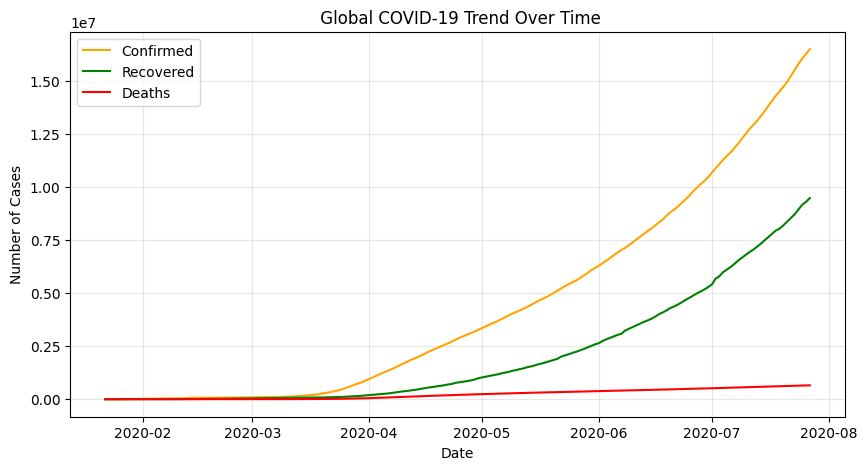

In [14]:
#EDA
# Global trend over time ---
global_trend = df_country.groupby('Date', as_index=False)[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum()

plt.figure(figsize=(10,5))
plt.plot(global_trend['Date'], global_trend['Confirmed'], label='Confirmed', color='orange')
plt.plot(global_trend['Date'], global_trend['Recovered'], label='Recovered', color='green')
plt.plot(global_trend['Date'], global_trend['Deaths'], label='Deaths', color='red')
plt.title(" Global COVID-19 Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


/tmp/ipython-input-241404739.py:14: UserWarning: Glyph 127758 (\N{EARTH GLOBE AMERICAS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127758 (\N{EARTH GLOBE AMERICAS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


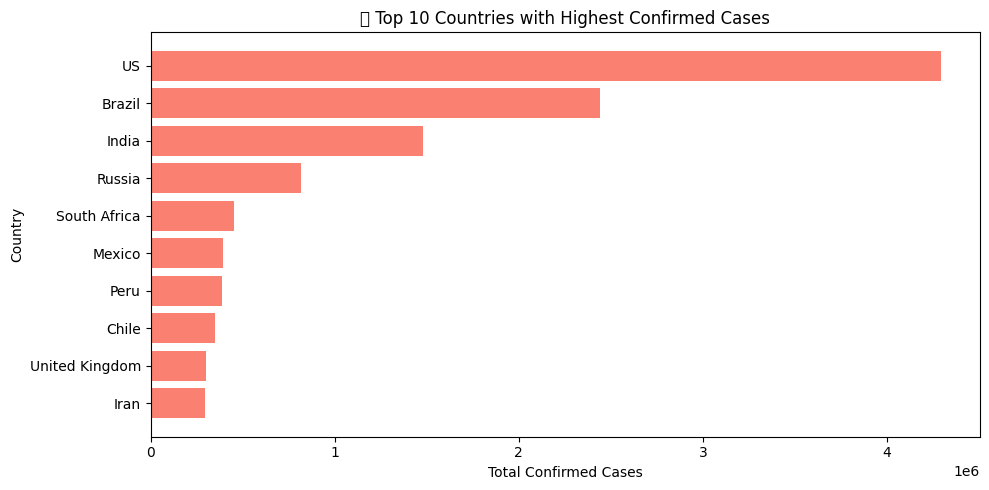

,Confirmed
Country/Region,
US,4290259
Brazil,2442375
India,1480073
Russia,816680
South Africa,452529
Mexico,395489
Peru,389717
Chile,347923
United Kingdom,301708


In [15]:
#  Top 10 countries by total confirmed cases ---
top_countries = (
    df_country.groupby('Country/Region')['Confirmed']
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color='salmon')
plt.title("🌎 Top 10 Countries with Highest Confirmed Cases")
plt.xlabel("Total Confirmed Cases")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

top_countries


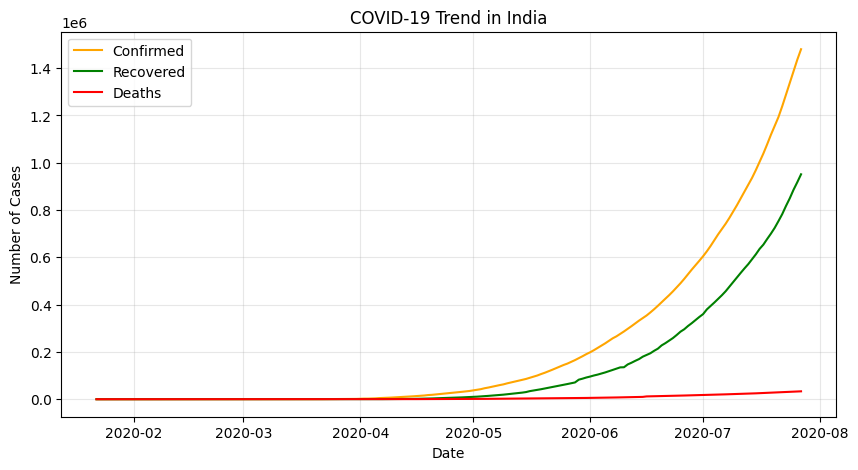

In [16]:
# Trend for a specific country (India) ---
country = 'India'
country_data = df_country[df_country['Country/Region'] == country]

plt.figure(figsize=(10,5))
plt.plot(country_data['Date'], country_data['Confirmed'], label='Confirmed', color='orange')
plt.plot(country_data['Date'], country_data['Recovered'], label='Recovered', color='green')
plt.plot(country_data['Date'], country_data['Deaths'], label='Deaths', color='red')
plt.title("COVID-19 Trend in India")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


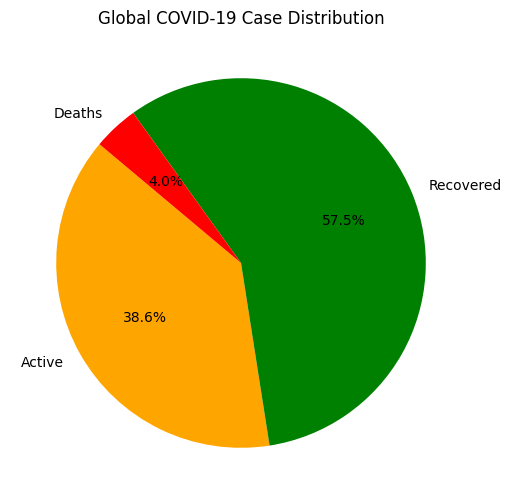

In [17]:
#  Global case distribution (latest date) ---
latest = df_country[df_country['Date'] == df_country['Date'].max()]
totals = latest[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum()

plt.figure(figsize=(6,6))
plt.pie(
    [totals['Active'], totals['Recovered'], totals['Deaths']],
    labels=['Active', 'Recovered', 'Deaths'],
    colors=['orange', 'green', 'red'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Global COVID-19 Case Distribution")
plt.show()


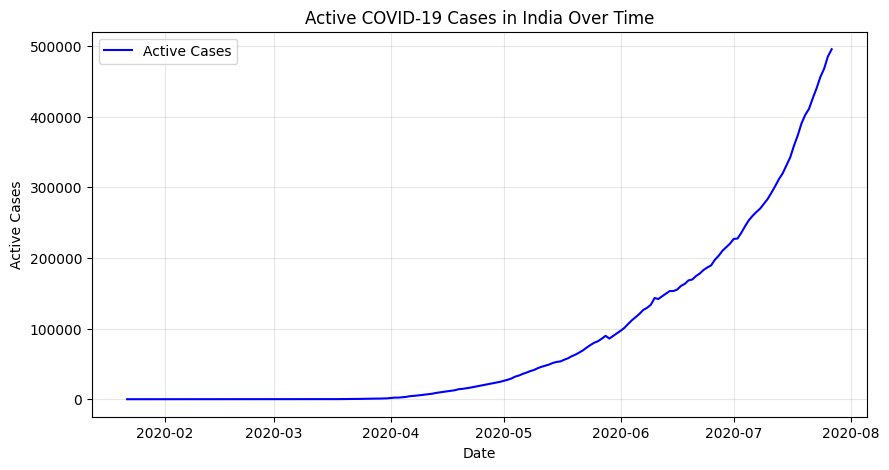

In [18]:
plt.figure(figsize=(10,5))
plt.plot(country_data['Date'], country_data['Active'], label='Active Cases', color='blue')
plt.title("Active COVID-19 Cases in India Over Time")
plt.xlabel("Date")
plt.ylabel("Active Cases")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


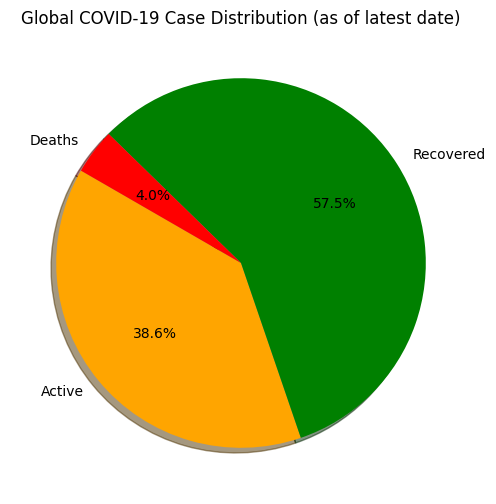

Date: 2020-07-27 00:00:00
Active       6358362
Recovered    9468087
Deaths        654036
dtype: int64


In [19]:
#Global case distribution (latest date) ---

# 1️⃣ Extract the most recent date
latest_date = df_country['Date'].max()

# 2️⃣ Filter dataset for that date
latest_data = df_country[df_country['Date'] == latest_date]

# 3️⃣ Sum all metrics globally
global_totals = latest_data[['Active', 'Recovered', 'Deaths']].sum()

# 4️⃣ Plot a pie chart
plt.figure(figsize=(6,6))
plt.pie(
    [global_totals['Active'], global_totals['Recovered'], global_totals['Deaths']],
    labels=['Active', 'Recovered', 'Deaths'],
    colors=['orange', 'green', 'red'],
    autopct='%1.1f%%',
    startangle=150,
    shadow=True
)
plt.title("Global COVID-19 Case Distribution (as of latest date)")
plt.show()

# 5️⃣ Optional: print the totals
print("Date:", latest_date)
print(global_totals)


In [20]:
# --- Step 1: Sort by Country and Date ---
df_country = df_country.sort_values(by=['Country/Region', 'Date'])

# --- Step 2: Compute Daily New Cases ---
df_country['New_Confirmed'] = df_country.groupby('Country/Region')['Confirmed'].diff().fillna(0)
df_country['New_Deaths'] = df_country.groupby('Country/Region')['Deaths'].diff().fillna(0)
df_country['New_Recovered'] = df_country.groupby('Country/Region')['Recovered'].diff().fillna(0)

# --- Step 3: Compute Rates (% values) ---
df_country['Recovery_Rate'] = (df_country['Recovered'] / df_country['Confirmed']) * 100
df_country['Fatality_Rate'] = (df_country['Deaths'] / df_country['Confirmed']) * 100

# --- Step 4: Compute Daily Growth Rate ---
df_country['Daily_Growth_Rate'] = df_country.groupby('Country/Region')['Confirmed'].pct_change() * 100
df_country['Daily_Growth_Rate'] = df_country['Daily_Growth_Rate'].replace([np.inf, -np.inf], 0).fillna(0)

# --- Step 5: Display final dataset ---
df_country.head(10)


,Country/Region,Date,Confirmed,Deaths,Recovered,Active,New_Confirmed,New_Deaths,New_Recovered,Recovery_Rate,Fatality_Rate,Daily_Growth_Rate
0,Afghanistan,2020-01-22,0,0,0,0,0.0,0.0,0.0,NaN,NaN,0.0
1,Afghanistan,2020-01-23,0,0,0,0,0.0,0.0,0.0,NaN,NaN,0.0
2,Afghanistan,2020-01-24,0,0,0,0,0.0,0.0,0.0,NaN,NaN,0.0
3,Afghanistan,2020-01-25,0,0,0,0,0.0,0.0,0.0,NaN,NaN,0.0
4,Afghanistan,2020-01-26,0,0,0,0,0.0,0.0,0.0,NaN,NaN,0.0
5,Afghanistan,2020-01-27,0,0,0,0,0.0,0.0,0.0,NaN,NaN,0.0
6,Afghanistan,2020-01-28,0,0,0,0,0.0,0.0,0.0,NaN,NaN,0.0
7,Afghanistan,2020-01-29,0,0,0,0,0.0,0.0,0.0,NaN,NaN,0.0
8,Afghanistan,2020-01-30,0,0,0,0,0.0,0.0,0.0,NaN,NaN,0.0
9,Afghanistan,2020-01-31,0,0,0,0,0.0,0.0,0.0,NaN,NaN,0.0


In [21]:
latest_date = df_country['Date'].max()
global_rates = df_country[df_country['Date'] == latest_date][['Recovery_Rate', 'Fatality_Rate']].mean()
print("Global Average Recovery Rate: {:.2f}%".format(global_rates['Recovery_Rate']))
print("Global Average Fatality Rate: {:.2f}%".format(global_rates['Fatality_Rate']))


Global Average Recovery Rate: 64.82%
Global Average Fatality Rate: 3.02%


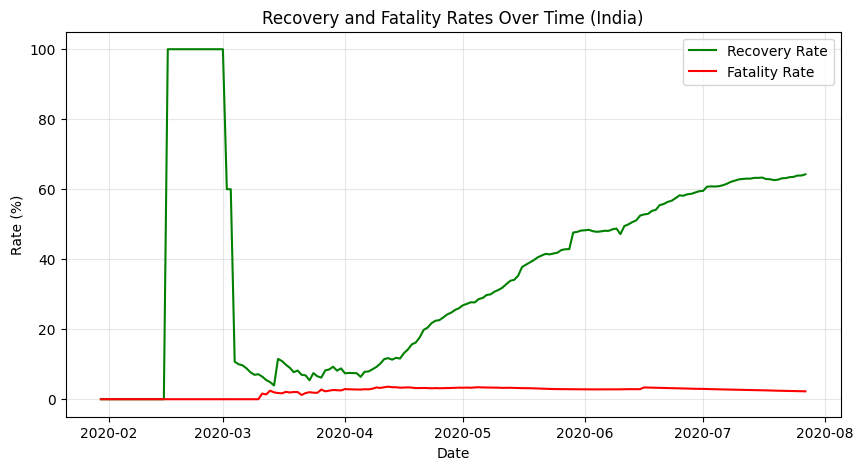

In [22]:
india = df_country[df_country['Country/Region'] == 'India']

plt.figure(figsize=(10,5))
plt.plot(india['Date'], india['Recovery_Rate'], label='Recovery Rate', color='green')
plt.plot(india['Date'], india['Fatality_Rate'], label='Fatality Rate', color='red')
plt.title("Recovery and Fatality Rates Over Time (India)")
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [1]:
# --- STEP 1: CLEAN INSTALL ---
!pip uninstall -y prophet cmdstanpy pystan
!pip install numpy==1.26.4 pandas==2.2.2 matplotlib==3.9.2 pillow==10.3.0 --force-reinstall
!pip install prophet==1.1.5 cmdstanpy==1.2.0 --no-cache-dir



Found existing installation: prophet 1.1.7
Uninstalling prophet-1.1.7:
  Successfully uninstalled prophet-1.1.7
Found existing installation: cmdstanpy 1.3.0
Uninstalling cmdstanpy-1.3.0:
  Successfully uninstalled cmdstanpy-1.3.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.6

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 151.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 180.5 MB/s eta 0:00:00
  Attempting uninstall: stanio
    Found existing installation: stanio 0.5.1
    Uninstalling stanio-0.5.1:
      Successfully uninstalled stanio-0.5.1


In [37]:
# Filter India data
india = df_country[df_country['Country/Region'] == 'India'][['Date', 'Confirmed']]

# Rename for Prophet
india = india.rename(columns={'Date': 'ds', 'Confirmed': 'y'})

# Prophet requires datetime format
india['ds'] = pd.to_datetime(india['ds'])

india.head()


,ds,y
14852,2020-01-22,0
14853,2020-01-23,0
14854,2020-01-24,0
14855,2020-01-25,0
14856,2020-01-26,0


In [40]:


def plot_prophet_forecast(model, forecast, actual_df, country_name="India"):
    """
    Clean, warning-free Prophet forecast plot.

    Parameters:
        model        : trained Prophet model
        forecast     : Prophet forecast DataFrame (from model.predict)
        actual_df    : original country data with columns ['ds', 'y']
        country_name : name of the country for title (default = 'India')
    """

    # Convert 'ds' to numpy datetime array to avoid FutureWarning
    dates = np.array(forecast['ds'], dtype='datetime64[ns]')

    plt.figure(figsize=(10,5))

    # Predicted mean line
    plt.plot(dates, forecast['yhat'], color='blue', label='Predicted (Prophet)')

    # Confidence interval
    plt.fill_between(
        dates,
        forecast['yhat_lower'],
        forecast['yhat_upper'],
        color='lightblue',
        alpha=0.5,
        label='Confidence Interval'
    )

    # Actual historical data
    plt.scatter(actual_df['ds'], actual_df['y'], color='black', s=12, label='Actual Data')

    plt.title(f"COVID-19 Confirmed Cases Forecast for {country_name} (Prophet Model)")
    plt.xlabel("Date")
    plt.ylabel("Confirmed Cases")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()




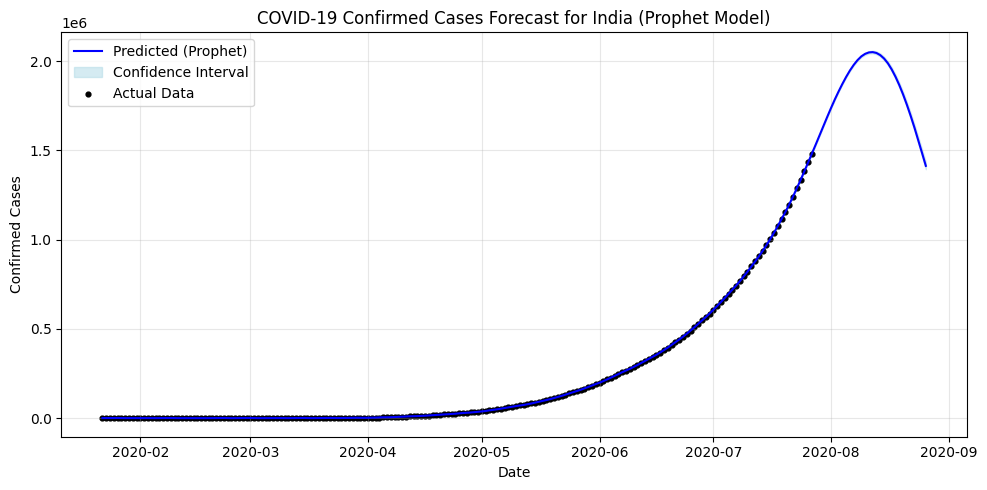

In [41]:
# --- Forecast and visualize (warning-free) ---

# Create future and forecast
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Plot using the custom function
plot_prophet_forecast(model, forecast, india, country_name="India")
